# Benchmark Params
Benchmark notebook for training logs, curves, confusion matrix, and evaluation metrics

In [1]:
from pathlib import Path
import sys
import yaml
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

from src.trainer import train_baseline, build_model, prepare_ann_dataloaders, resolve_device
from src.utils import load_config

OUTPUT_FIGURE_DIR = PROJECT_ROOT / 'reports' / 'figure' / '02_training'
OUTPUT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINTS_DIR = PROJECT_ROOT / 'checkpoints'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'


/home/coronny/sentiment_analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/coronny/sentiment_analysis/.venv/lib/python3.13/site-packages/pyvi/ViTokenizer.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  model = pickle.load(fin)


## 1) Train baseline and load history

In [ ]:
history = train_baseline(str(PROJECT_ROOT / 'configs' / 'ann_tfidf_sota.yaml'))
config = load_config(PROJECT_ROOT / 'configs' / 'ann_tfidf_sota.yaml')
model_name = config['models']['model_name'].lower()
history_path = OUTPUTS_DIR / f'{model_name}_history.yaml'
if history_path.exists():
    with open(history_path, 'r', encoding='utf-8') as f:
        history = yaml.safe_load(f)
history

---Đang tải datasets UIT ---


Saving the dataset (1/1 shards): 100%|██████████| 3166/3166 [00:00<00:00, 579471.39 examples/s]


Đã tải xong! Train: 11426 câu.


/home/coronny/sentiment_analysis/.venv/lib/python3.13/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/26 16:23:40 INFO mlflow.tracking.fluent: Experiment with name 'vsfc_ann_baseline' does not exist. Creating a new experiment.


Epoch 1/10 | Train Loss: 1.0409 | Val Loss: 0.8814 | Train Acc: 0.4408 | Val Acc: 0.8124
Epoch 2/10 | Train Loss: 0.7013 | Val Loss: 0.6336 | Train Acc: 0.8669 | Val Acc: 0.8882
Epoch 3/10 | Train Loss: 0.5667 | Val Loss: 0.5671 | Train Acc: 0.8930 | Val Acc: 0.8932
Epoch 4/10 | Train Loss: 0.5087 | Val Loss: 0.5285 | Train Acc: 0.9040 | Val Acc: 0.9078
Epoch 5/10 | Train Loss: 0.4584 | Val Loss: 0.5020 | Train Acc: 0.9105 | Val Acc: 0.9109
Epoch 6/10 | Train Loss: 0.4275 | Val Loss: 0.4726 | Train Acc: 0.9123 | Val Acc: 0.9002
Epoch 7/10 | Train Loss: 0.3920 | Val Loss: 0.4584 | Train Acc: 0.9127 | Val Acc: 0.9015
Epoch 8/10 | Train Loss: 0.3711 | Val Loss: 0.4503 | Train Acc: 0.9088 | Val Acc: 0.8958
Epoch 9/10 | Train Loss: 0.3485 | Val Loss: 0.4497 | Train Acc: 0.9102 | Val Acc: 0.8989


2026/04/26 16:23:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/26 16:23:50 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Epoch 10/10 | Train Loss: 0.3334 | Val Loss: 0.4517 | Train Acc: 0.9087 | Val Acc: 0.8970
Saved model to: models/ann_baseline_model.pt
Saved vectorizer to: models/tfidf_vectorizer.pkl
Saved config/history to: outputs


{'train_loss': [1.0408926799310652,
  0.7012506670958503,
  0.5666584046609575,
  0.5086674798467306,
  0.4583890993959744,
  0.4274846474801362,
  0.3920015254833179,
  0.37109247665831496,
  0.348467356686652,
  0.33336661520866706],
 'val_loss': [0.8814434778690338,
  0.6336156904697419,
  0.5670833802223205,
  0.5284859824180603,
  0.5019577017426491,
  0.4725570669770241,
  0.458376778960228,
  0.4503077383339405,
  0.4497426773607731,
  0.4517234590649605],
 'train_acc': [0.44083668825485733,
  0.8668825485734291,
  0.892963416768773,
  0.9039908979520392,
  0.9104673551549098,
  0.9123052686854543,
  0.912655347453177,
  0.9088044810082269,
  0.9102047960791178,
  0.9087169613162962],
 'val_acc': [0.8123815540113708,
  0.8881869867340493,
  0.8932406822488945,
  0.9077700568540745,
  0.9109286165508528,
  0.9001895135818067,
  0.901452937460518,
  0.8957675300063171,
  0.8989260897030954,
  0.8970309538850284]}

## 2) Plot training curves (Loss and Accuracy)

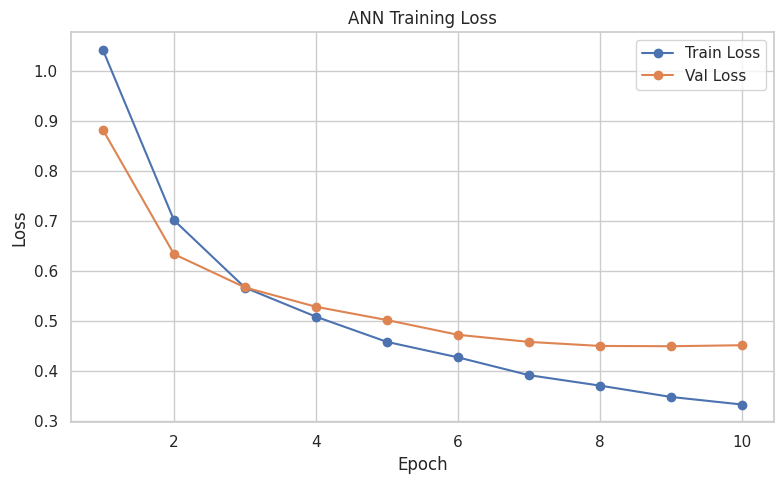

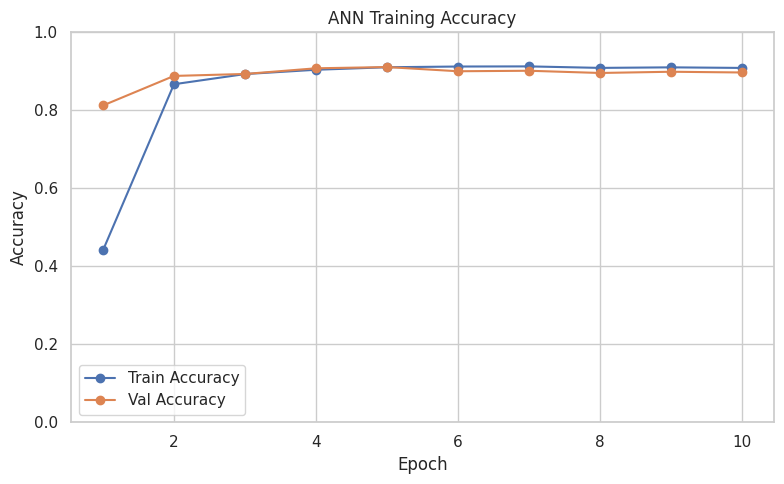

Saved: /home/coronny/sentiment_analysis/reports/figure/02_training/ann_feature1000_dropout0.3_loss.png
Saved: /home/coronny/sentiment_analysis/reports/figure/02_training/ann_feature1000_dropout0.3_accuracy.png


In [3]:
epochs = np.arange(1, len(history['train_loss']) + 1)
dropout_text = str(config['models']['ann']['dropout'])
max_features = config['data'].get('max_features', config['data'].get('max_Features'))
base_name = f"{model_name}_feature{max_features}_dropout{dropout_text}"

sns.set_theme(style='whitegrid')

plt.figure(figsize=(8, 5))
plt.plot(epochs, history['train_loss'], marker='o', label='Train Loss')
plt.plot(epochs, history['val_loss'], marker='o', label='Val Loss')
plt.title(f'{model_name.upper()} Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
loss_path = OUTPUT_FIGURE_DIR / f'{base_name}_loss.png'
plt.tight_layout()
plt.savefig(loss_path, dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history['train_acc'], marker='o', label='Train Accuracy')
plt.plot(epochs, history['val_acc'], marker='o', label='Val Accuracy')
plt.title(f'{model_name.upper()} Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()
acc_path = OUTPUT_FIGURE_DIR / f'{base_name}_accuracy.png'
plt.tight_layout()
plt.savefig(acc_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved: {loss_path}')
print(f'Saved: {acc_path}')

## 3) Evaluate best checkpoint on validation set

In [4]:
device = resolve_device(config['training']['device'])
_, val_loader, _ = prepare_ann_dataloaders(config)
model = build_model(config).to(device)
best_ckpt_path = CHECKPOINTS_DIR / f'{model_name}_best_model.pt'
ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

all_true, all_pred = [], []
with torch.no_grad():
    for x_batch, y_batch in val_loader:
        x_batch = x_batch.to(device)
        logits = model(x_batch)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_pred.extend(preds.tolist())
        all_true.extend(y_batch.numpy().tolist())

acc = accuracy_score(all_true, all_pred)
precision, recall, f1, _ = precision_recall_fscore_support(all_true, all_pred, average='macro', zero_division=0)
metrics = {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}
metrics

---Đang tải datasets UIT ---


Saving the dataset (1/1 shards): 100%|██████████| 3166/3166 [00:00<00:00, 540264.72 examples/s]


Đã tải xong! Train: 11426 câu.


{'accuracy': 0.8989260897030954,
 'precision': 0.7540517068662366,
 'recall': 0.8215043732106827,
 'f1': 0.7758577680762208}

## 4) Plot confusion matrix

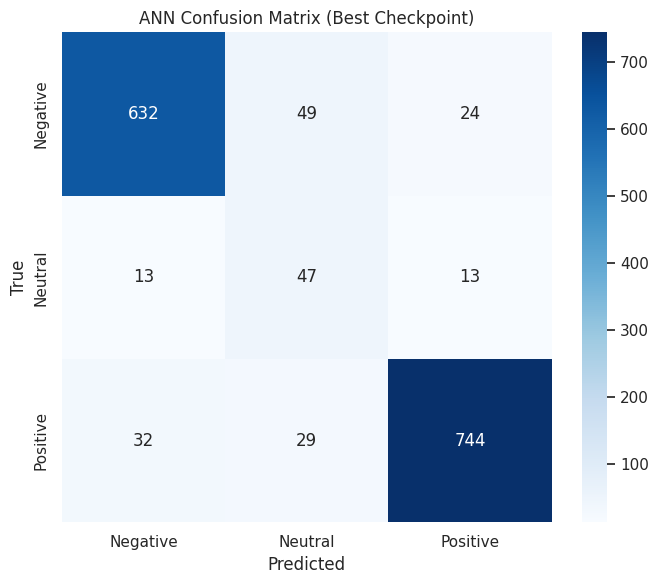

Saved: /home/coronny/sentiment_analysis/reports/figure/02_training/ann_confusion_matrix.png


In [5]:
label_names = ['Negative', 'Neutral', 'Positive']
cm = confusion_matrix(all_true, all_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title(f'{model_name.upper()} Confusion Matrix (Best Checkpoint)')
plt.xlabel('Predicted')
plt.ylabel('True')
cm_path = OUTPUT_FIGURE_DIR / f'{model_name}_confusion_matrix.png'
plt.tight_layout()
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {cm_path}')

## 5) Plot metrics bar chart

/tmp/ipykernel_43119/4030337518.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='viridis')


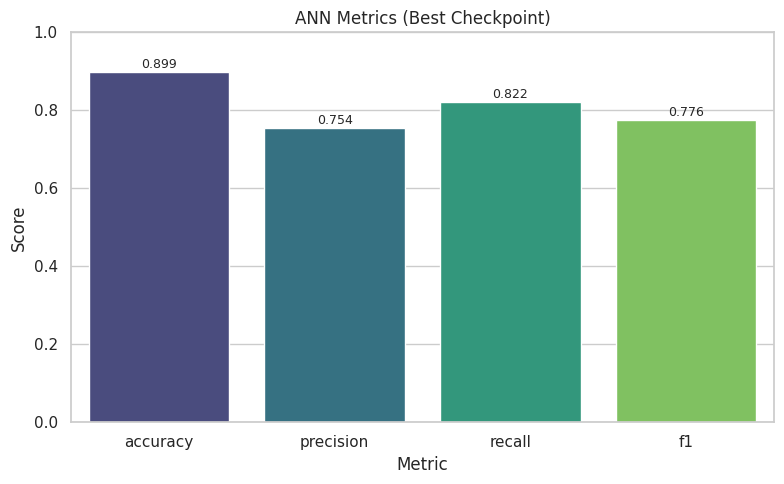

Saved: /home/coronny/sentiment_analysis/reports/figure/02_training/ann_metrics.png


In [6]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='viridis')
for i, v in enumerate(metrics.values()):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.ylim(0, 1)
plt.title(f'{model_name.upper()} Metrics (Best Checkpoint)')
plt.xlabel('Metric')
plt.ylabel('Score')
metric_path = OUTPUT_FIGURE_DIR / f'{model_name}_metrics.png'
plt.tight_layout()
plt.savefig(metric_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {metric_path}')